<a href="https://colab.research.google.com/github/ddd96vc-netizen/programas/blob/main/Due%C3%B1as_Daniel_AP_Final_Curriculum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trabajo Final de Analisis Profundo

VISION TRANSFORMER BENCHMARK PIPELINE

Ejecutar en Google Colab con GPU activada

In [ ]:
!pip install -q transformers timm Pillow requests matplotlib seaborn numpy torch torchvision

Imports y configuración

In [ ]:
import random
import time
import warnings
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import requests
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
)

warnings.filterwarnings("ignore")

# Semilla fija para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# Carpeta de salida para guardar las figuras
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Figuras se guardarán en: {OUTPUT_DIR.resolve()}")


Dispositivo: cuda
Figuras se guardarán en: /content/outputs


Cargar los cuatro modelos

In [ ]:
# ViT-B/16
VIT_HF   = "google/vit-base-patch16-224"
vit_proc  = AutoImageProcessor.from_pretrained(VIT_HF)
vit_model = AutoModelForImageClassification.from_pretrained(
    VIT_HF, output_attentions=True
).to(DEVICE).eval()
print("  ✓ ViT-B/16 cargado")

#DeiT-B
DEIT_HF   = "facebook/deit-base-distilled-patch16-224"
deit_proc  = AutoImageProcessor.from_pretrained(DEIT_HF)
deit_model = AutoModelForImageClassification.from_pretrained(
    DEIT_HF, output_attentions=True
).to(DEVICE).eval()
print("  ✓ DeiT-B cargado")

# Swin-T
SWIN_HF   = "microsoft/swin-tiny-patch4-window7-224"
swin_proc  = AutoImageProcessor.from_pretrained(SWIN_HF)
swin_model = AutoModelForImageClassification.from_pretrained(
    SWIN_HF
).to(DEVICE).eval()
print("  ✓ Swin-T cargado")

# ResNet-50
resnet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet_model = resnet_model.to(DEVICE).eval()
resnet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
print("  ✓ ResNet-50 cargado")

# Diccionario unificado para iterar fácilmente
MODELS = {
    "ViT-B/16":  {"model": vit_model,    "proc": vit_proc,    "type": "hf"},
    "DeiT-B":    {"model": deit_model,   "proc": deit_proc,   "type": "hf"},
    "Swin-T":    {"model": swin_model,   "proc": swin_proc,   "type": "hf"},
    "ResNet-50": {"model": resnet_model, "proc": resnet_transform, "type": "tv"},
}
print("\nTodos los modelos listos.")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

  ✓ Swin-T cargado
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 97.5MB/s]


  ✓ ResNet-50 cargado

Todos los modelos listos.


Descargar 50 imágenes y cachearlas para futuros usos

In [ ]:

import os, json
from pathlib import Path
from google.colab import drive

random.seed(SEED)
N_IMAGES   = 50
IMG_SIZE   = 224
drive.mount('/content/drive')
CACHE_DIR = Path("/content/drive/MyDrive/vit_cache")
CACHE_DIR.mkdir(exist_ok=True)
META_FILE  = CACHE_DIR / "metadata.json"

SEEDS_PICSUM = random.sample(range(1, 9999), N_IMAGES)

#Si ya existe el cache, cargar directamente sin descargar
if META_FILE.exists():
    print("Cache encontrado — cargando imágenes desde disco...")
    meta = json.loads(META_FILE.read_text())
    images   = []
    img_urls = []
    for entry in meta:
        img = Image.open(entry["path"]).convert("RGB")
        images.append(img)
        img_urls.append(entry["url"])
    print(f"  {len(images)} imágenes cargadas desde {CACHE_DIR}/")

#Si no existe, descargar y guardar
else:
    print(f"No hay cache — descargando {N_IMAGES} imágenes y guardándolas...")
    images   = []
    img_urls = []
    meta     = []

    for i, s in enumerate(SEEDS_PICSUM):
        url  = f"https://picsum.photos/seed/{s}/{IMG_SIZE}/{IMG_SIZE}"
        path = CACHE_DIR / f"img_{i:03d}_seed{s}.jpg"

        for attempt in range(4):
            try:
                resp = requests.get(url, timeout=15)
                resp.raise_for_status()
                img  = Image.open(BytesIO(resp.content)).convert("RGB")
                img.save(path, format="JPEG", quality=95)   # guardar en disco
                images.append(img)
                img_urls.append(url)
                meta.append({"idx": i, "seed": s, "url": url, "path": str(path)})
                break
            except Exception as e:
                if attempt == 3:
                    print(f"  ✗ Error imagen {i+1} (seed={s}): {e}")
                time.sleep(1.5)

        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{N_IMAGES} descargadas")

    # Guardar metadata con URLs y rutas para referencia futura
    META_FILE.write_text(json.dumps(meta, indent=2))
    print(f"\n✓ {len(images)} imágenes guardadas en '{CACHE_DIR}/'")
    print(f"✓ Metadata guardada en '{META_FILE}'")

print(f"\nTotal imágenes disponibles: {len(images)}")

Mounted at /content/drive
Cache encontrado — cargando imágenes desde disco...
  50 imágenes cargadas desde /content/drive/MyDrive/vit_cache/

Total imágenes disponibles: 50


Inferencia sobre las 50 imágenes

In [ ]:
def run_inference_hf(model, processor, img, device):
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs)
    probs     = F.softmax(out.logits, dim=-1)[0]
    top1_conf = probs.max().item() * 100
    top1_id   = probs.argmax().item()
    attentions = out.attentions if hasattr(out, "attentions") else None
    return top1_conf, top1_id, attentions

def run_inference_tv(model, transform, img, device):
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
    probs     = F.softmax(logits, dim=-1)[0]
    top1_conf = probs.max().item() * 100
    top1_id   = probs.argmax().item()
    return top1_conf, top1_id, None

results = {name: {"confs": [], "class_ids": []} for name in MODELS}
raw_attentions = {name: [] for name in ["ViT-B/16", "DeiT-B"]}

print("Ejecutando inferencia...")
for img_idx, img in enumerate(images):
    for name, cfg in MODELS.items():
        if cfg["type"] == "hf":
            conf, cid, attns = run_inference_hf(
                cfg["model"], cfg["proc"], img, DEVICE
            )
            if name in raw_attentions:
                raw_attentions[name].append(attns)
        else:
            conf, cid, _ = run_inference_tv(
                cfg["model"], cfg["proc"], img, DEVICE
            )
        results[name]["confs"].append(conf)
        results[name]["class_ids"].append(cid)

    if (img_idx + 1) % 10 == 0:
        print(f"  {img_idx+1}/{len(images)} imágenes procesadas")

print("\nInferencia completa.")

Ejecutando inferencia...
  10/50 imágenes procesadas
  20/50 imágenes procesadas
  30/50 imágenes procesadas
  40/50 imágenes procesadas
  50/50 imágenes procesadas

Inferencia completa.


Estadísticas por modelo

In [ ]:
print(f"{'Modelo':<12} {'Media':>7} {'Std':>7} {'Mín':>7} {'Máx':>7}")
print("─" * 44)

stats = {}
for name, res in results.items():
    confs = np.array(res["confs"])
    stats[name] = {
        "mean": confs.mean(),
        "std":  confs.std(),
        "min":  confs.min(),
        "max":  confs.max(),
        "confs": confs,
    }
    print(f"{name:<12} {confs.mean():>6.2f}%  {confs.std():>6.2f}%  "
          f"{confs.min():>6.2f}%  {confs.max():>6.2f}%")

print("─" * 44)

Modelo         Media     Std     Mín     Máx
────────────────────────────────────────────
ViT-B/16      51.00%   32.97%    4.67%   99.89%
DeiT-B        65.08%   27.14%   15.03%   99.60%
Swin-T        41.48%   24.21%    7.69%   95.95%
ResNet-50     40.32%   25.05%    4.06%   99.53%
────────────────────────────────────────────


Visualizaciones (boxplot, heatmap, barras)

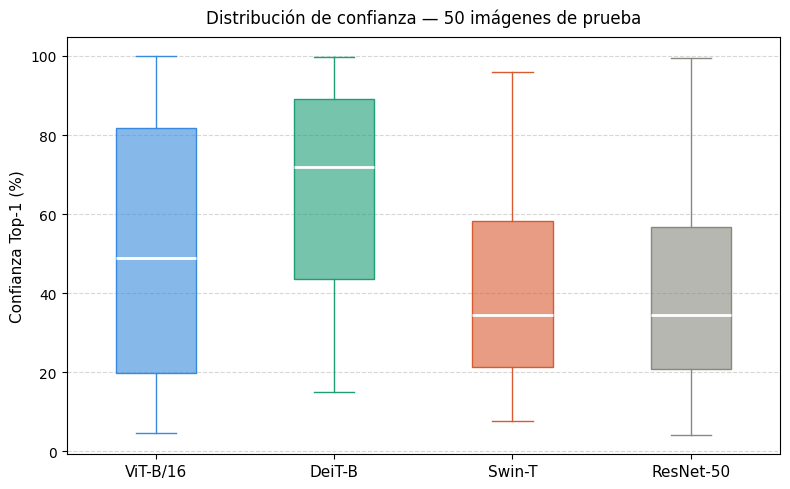

✓ Boxplot guardado


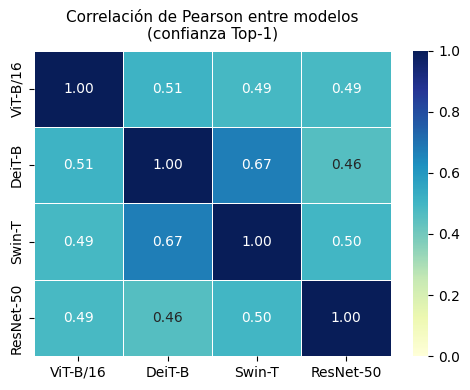

✓ Heatmap guardado


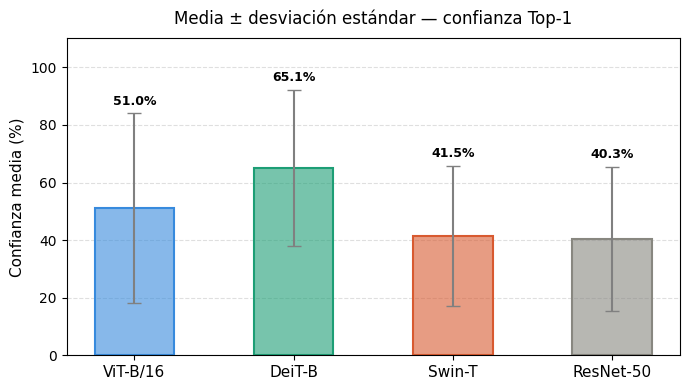

✓ Gráfico de barras guardado


In [ ]:
MODEL_NAMES  = list(MODELS.keys())
COLORS_PLOT  = ["#378ADD", "#1D9E75", "#D85A30", "#888780"]

#Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
data_box = [stats[n]["confs"] for n in MODEL_NAMES]
bp = ax.boxplot(
    data_box,
    patch_artist=True,
    notch=False,
    widths=0.45,
    medianprops={"color": "white", "linewidth": 2},
)
for patch, color in zip(bp["boxes"], COLORS_PLOT):
    patch.set_facecolor(color + "99")
    patch.set_edgecolor(color)
for whisker, cap in zip(bp["whiskers"], bp["caps"]):
    idx = bp["whiskers"].index(whisker) // 2
    whisker.set_color(COLORS_PLOT[idx])
    cap.set_color(COLORS_PLOT[idx])
for flier, color in zip(bp["fliers"], COLORS_PLOT):
    flier.set(markerfacecolor=color, marker="o", alpha=0.5, markersize=4)

ax.set_xticks(range(1, len(MODEL_NAMES) + 1))
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel("Confianza Top-1 (%)", fontsize=11)
ax.set_title(f"Distribución de confianza — {len(images)} imágenes de prueba", fontsize=12, pad=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplot_confianza.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Boxplot guardado")

#Heatmap de correlación
conf_matrix = np.array([stats[n]["confs"] for n in MODEL_NAMES])
corr_matrix = np.corrcoef(conf_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=MODEL_NAMES,
    yticklabels=MODEL_NAMES,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlación de Pearson entre modelos\n(confianza Top-1)", fontsize=11, pad=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Heatmap guardado")

#Barras con error (media ± std)
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(MODEL_NAMES))
means = [stats[n]["mean"] for n in MODEL_NAMES]
stds  = [stats[n]["std"]  for n in MODEL_NAMES]

bars = ax.bar(x, means, yerr=stds, capsize=5, width=0.5,
              color=[c + "99" for c in COLORS_PLOT],
              edgecolor=COLORS_PLOT, linewidth=1.5,
              error_kw={"elinewidth": 1.5, "ecolor": "gray"})

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + std + 2,
            f"{mean:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel("Confianza media (%)", fontsize=11)
ax.set_title("Media ± desviación estándar — confianza Top-1", fontsize=12, pad=10)
margen_inf = max(0, min(means) - max(stds) - 10)
ax.set_ylim(margen_inf, max(means) + max(stds) + 12)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "barras_media_std.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Gráfico de barras guardado")

Seleccionar 3 imágenes representativas

In [ ]:
n_imgs = len(images)

def score_imagen_A(i):
    """Puntaje alto si todos los modelos tienen >70% y misma clase top-1."""
    confs = [results[m]["confs"][i] for m in MODEL_NAMES]
    ids   = [results[m]["class_ids"][i] for m in MODEL_NAMES]
    if min(confs) < 50:
        return -1
    agree = len(set(ids)) == 1
    return min(confs) + (20 if agree else 0)

def score_imagen_B(i):
    """Puntaje alto si hay máxima discrepancia entre modelos."""
    confs = [results[m]["confs"][i] for m in MODEL_NAMES]
    return max(confs) - min(confs)

def score_imagen_C(i):
    """Puntaje alto si todos los modelos tienen baja confianza."""
    confs = [results[m]["confs"][i] for m in MODEL_NAMES]
    return -max(confs)   # negativos → menor confianza gana

idx_A = max(range(n_imgs), key=score_imagen_A)
idx_B = max(range(n_imgs), key=score_imagen_B)
# Para C evitamos usar los mismos índices
cands = [i for i in range(n_imgs) if i not in (idx_A, idx_B)]
idx_C = max(cands, key=score_imagen_C)

repr_indices = {"A — alta confianza / acuerdo": idx_A,
                "B — discrepancia entre modelos": idx_B,
                "C — baja confianza / fallo": idx_C}

print("Imágenes representativas seleccionadas:")
for label, idx in repr_indices.items():
    confs = {m: f"{results[m]['confs'][idx]:.1f}%" for m in MODEL_NAMES}
    print(f"  Imagen {label}  →  índice {idx}")
    for m, c in confs.items():
        print(f"      {m:<12}: {c}")


Imágenes representativas seleccionadas:
  Imagen A — alta confianza / acuerdo  →  índice 10
      ViT-B/16    : 99.5%
      DeiT-B      : 99.5%
      Swin-T      : 86.0%
      ResNet-50   : 91.8%
  Imagen B — discrepancia entre modelos  →  índice 25
      ViT-B/16    : 98.8%
      DeiT-B      : 26.3%
      Swin-T      : 13.5%
      ResNet-50   : 9.7%
  Imagen C — baja confianza / fallo  →  índice 44
      ViT-B/16    : 5.1%
      DeiT-B      : 17.9%
      Swin-T      : 23.5%
      ResNet-50   : 12.1%


Extracción de mapas de atención (ViT y DeiT)

In [ ]:
def extract_attention_map(model, processor, img, device):
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs, output_attentions=True)

    last_attn = out.attentions[-1][0]   # (heads, seq, seq)
    avg_attn  = last_attn.mean(dim=0)   # (seq, seq)

    #FIX: detectar cuántos tokens especiales hay
    seq_len   = avg_attn.shape[0]
    n_patches = 196                     # siempre 196 para img 224 + patch 16
    n_special = seq_len - n_patches     # ViT→1  |  DeiT→2

    cls_attn  = avg_attn[0, n_special:]  # (196,)


    grid_size = int(n_patches ** 0.5)   # 14
    attn_map  = cls_attn.reshape(grid_size, grid_size).cpu().numpy()

    attn_pil  = Image.fromarray(attn_map).resize((224, 224), Image.BILINEAR)
    attn_arr  = np.array(attn_pil)
    attn_arr  = (attn_arr - attn_arr.min()) / (attn_arr.max() - attn_arr.min() + 1e-8)
    return attn_arr


#Calcula los mapas para las 3 imágenes representativas × 2 modelo
attention_maps = {}     # { "A": {"ViT-B/16": arr, "DeiT-B": arr}, "B": {...}, ... }
letter_map = {"A — alta confianza / acuerdo": "A",
              "B — discrepancia entre modelos": "B",
              "C — baja confianza / fallo": "C"}

for label, idx in repr_indices.items():
    letter = letter_map[label]
    attention_maps[letter] = {}
    img = images[idx]
    for mname, cfg in [("ViT-B/16", MODELS["ViT-B/16"]),
                        ("DeiT-B",   MODELS["DeiT-B"])]:
        attn = extract_attention_map(cfg["model"], cfg["proc"], img, DEVICE)
        attention_maps[letter][mname] = attn
        print(f"  ✓ Mapa de atención extraído: imagen {letter} — {mname}")

print("\nExtracción de mapas de atención completa.")

  ✓ Mapa de atención extraído: imagen A — ViT-B/16
  ✓ Mapa de atención extraído: imagen A — DeiT-B
  ✓ Mapa de atención extraído: imagen B — ViT-B/16
  ✓ Mapa de atención extraído: imagen B — DeiT-B
  ✓ Mapa de atención extraído: imagen C — ViT-B/16
  ✓ Mapa de atención extraído: imagen C — DeiT-B

Extracción de mapas de atención completa.


Figura comparativa por imagen representativa

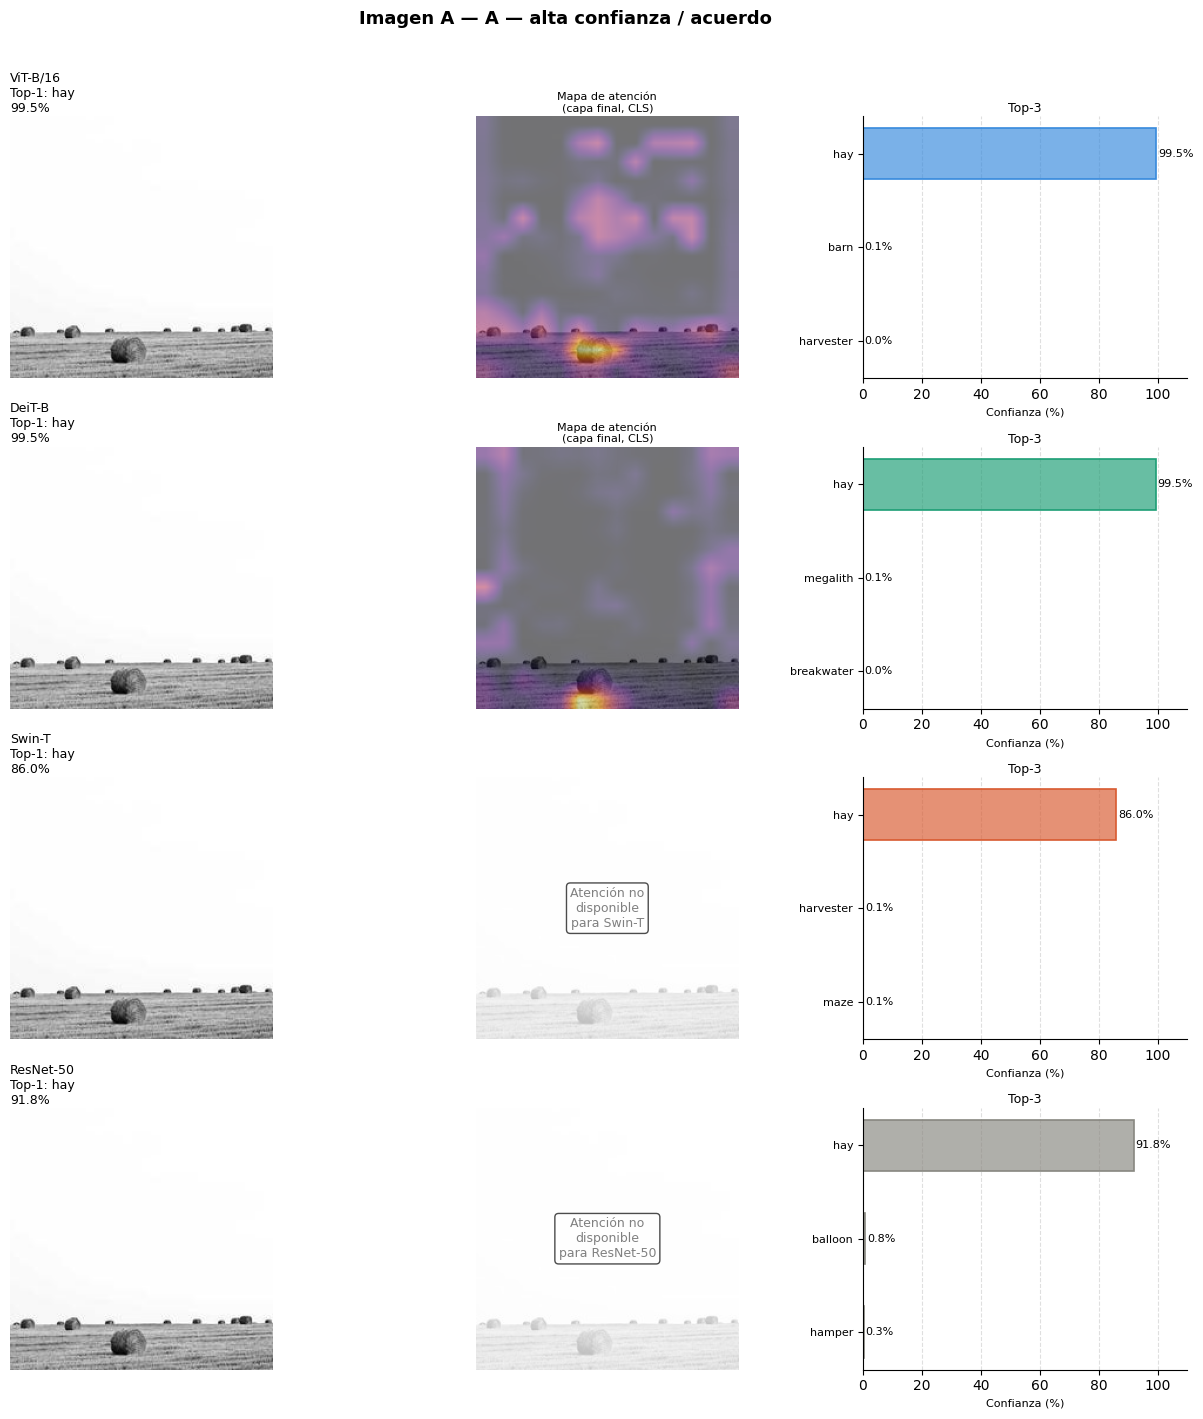

✓ Figura imagen A guardada: outputs/figura_imagen_A.png


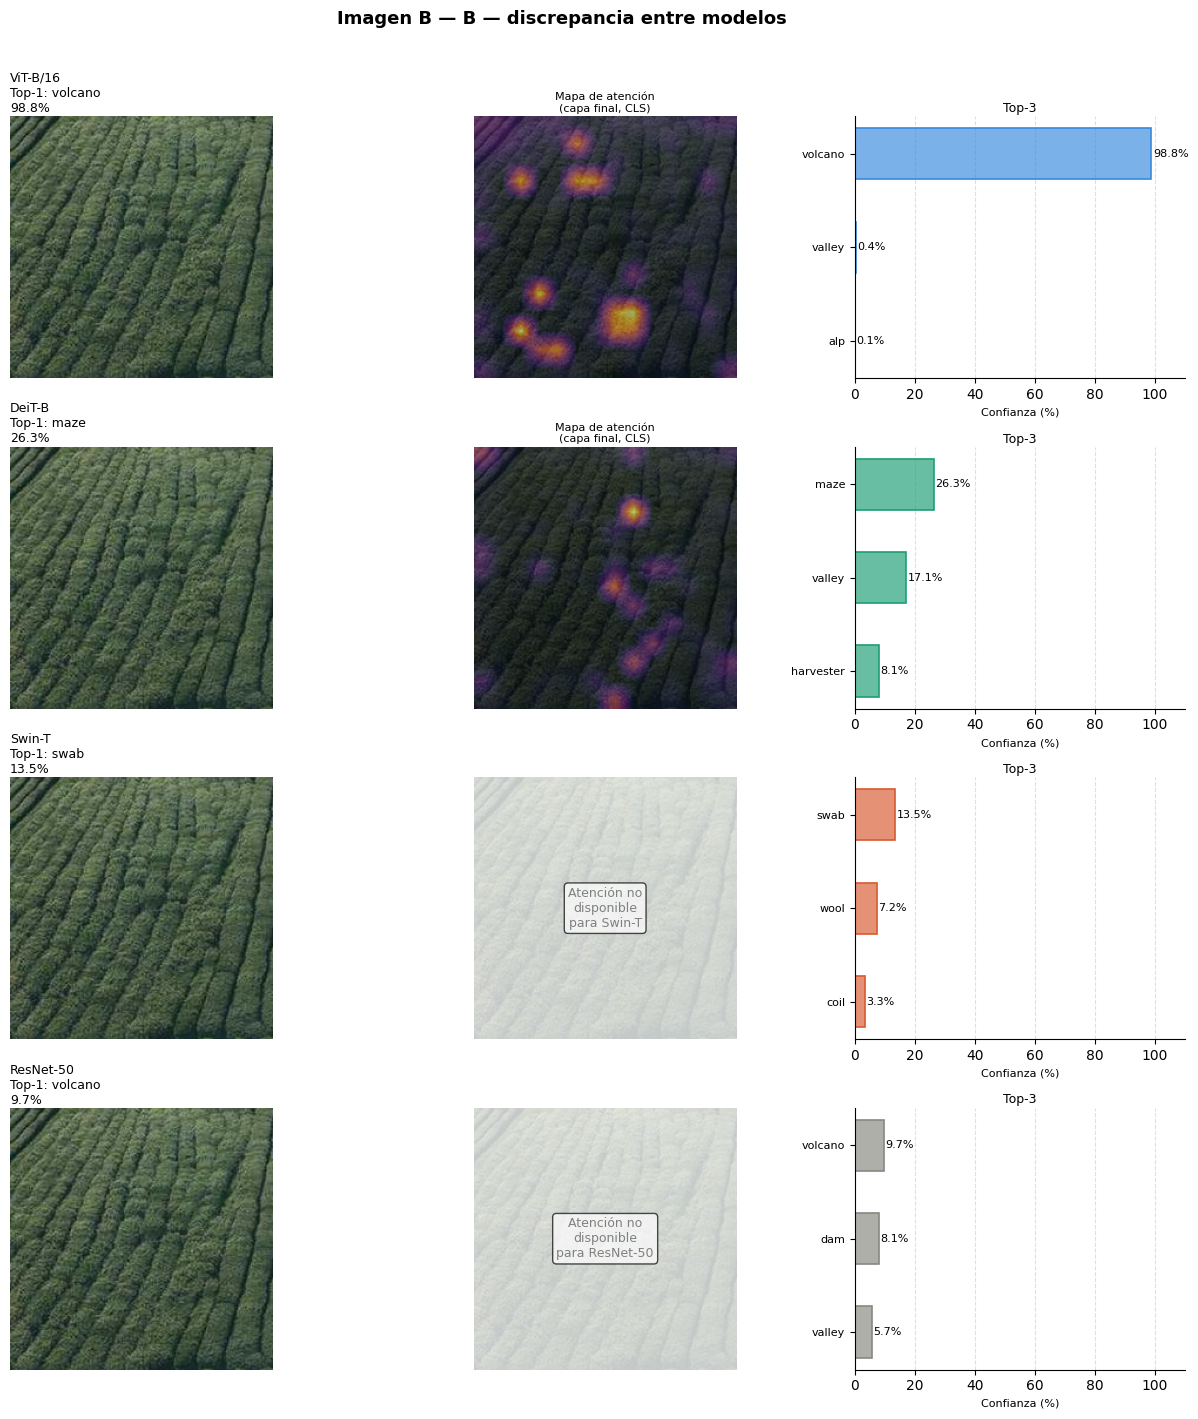

✓ Figura imagen B guardada: outputs/figura_imagen_B.png


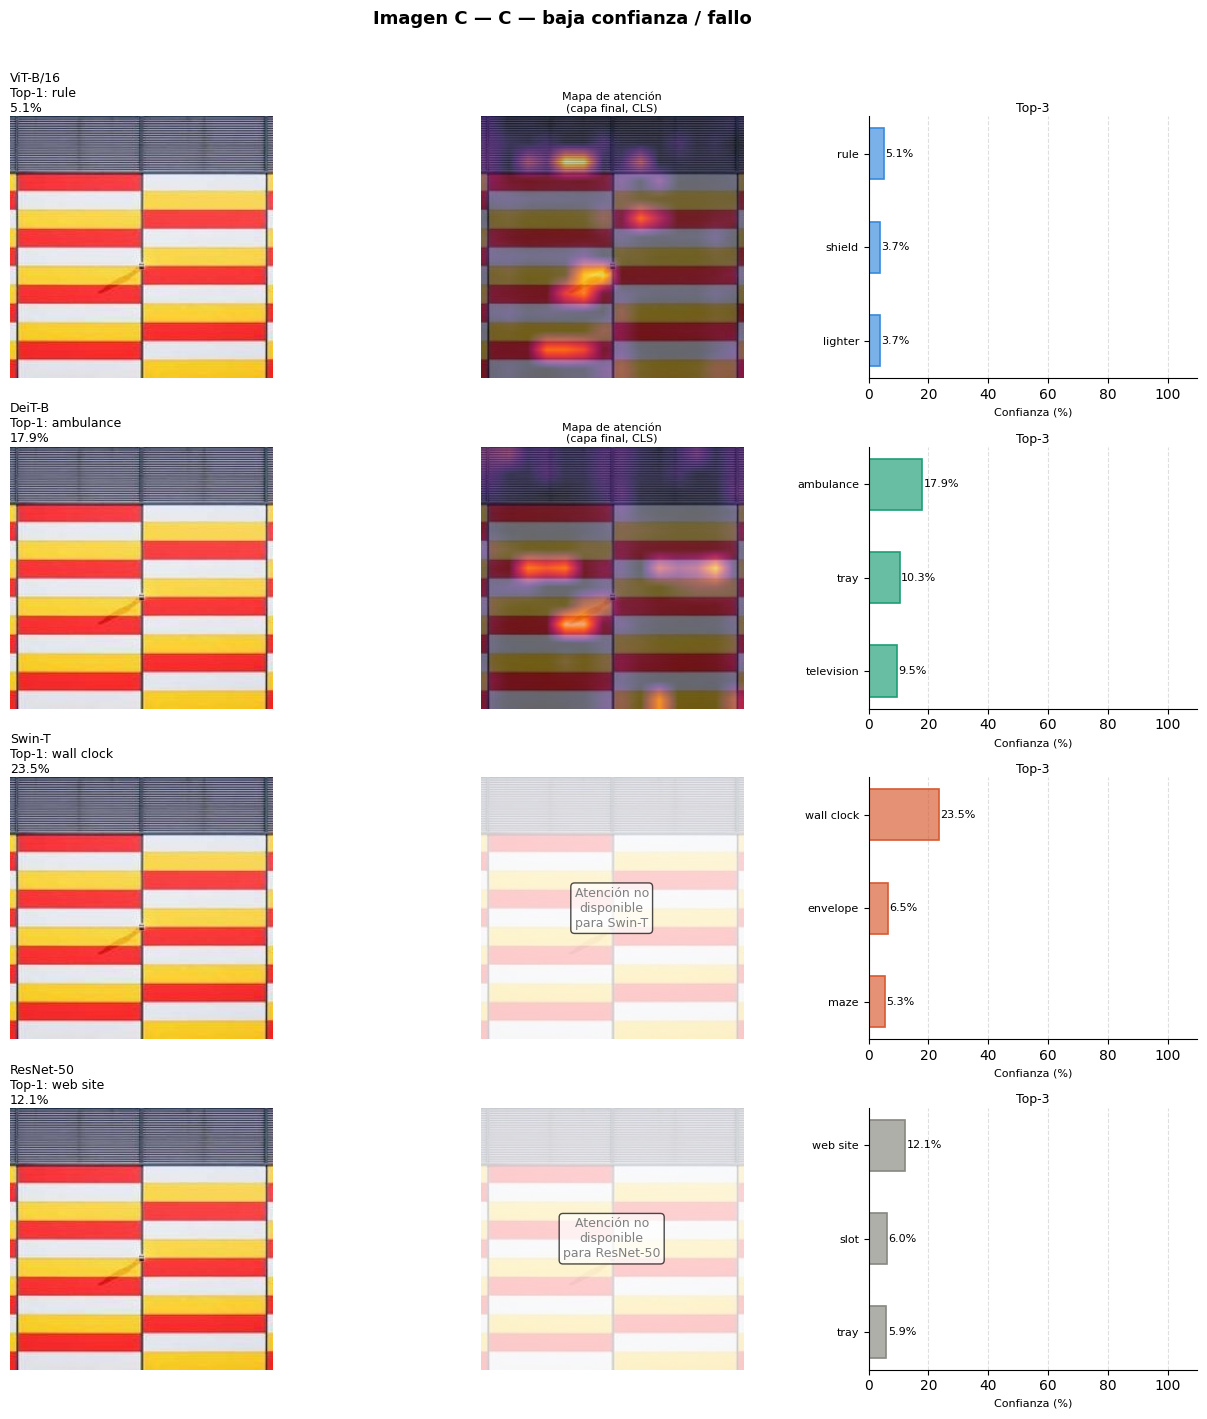

✓ Figura imagen C guardada: outputs/figura_imagen_C.png


In [ ]:
imagenet_labels = models.ResNet50_Weights.IMAGENET1K_V1.meta["categories"]

def top3_info(model_name, img_idx):
    """Devuelve lista de (nombre_clase, confianza%) para el Top-3."""
    cfg = MODELS[model_name]
    img = images[img_idx]
    if cfg["type"] == "hf":
        inputs = cfg["proc"](images=img, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = cfg["model"](**inputs).logits
        probs = F.softmax(logits, dim=-1)[0]
    else:
        tensor = cfg["proc"](img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = cfg["model"](tensor)
        probs = F.softmax(logits, dim=-1)[0]
    top3_vals, top3_ids = probs.topk(3)
    return [(imagenet_labels[cid.item()], val.item() * 100)
            for cid, val in zip(top3_ids, top3_vals)]


#Colores de barras para Top-3
BAR_COLORS = ["#378ADD", "#1D9E75", "#D85A30", "#888780"]

def plot_representative_image(letter, idx, label_title):
    fig, axes = plt.subplots(
        4, 3,
        figsize=(13, 14),
        gridspec_kw={"width_ratios": [1.3, 1.3, 1]}
    )
    fig.suptitle(f"Imagen {letter} — {label_title}", fontsize=13, y=1.01, fontweight="bold")
    img = images[idx]
    img_arr = np.array(img)

    has_attn = {"ViT-B/16": True, "DeiT-B": True, "Swin-T": False, "ResNet-50": False}
    cmap_attn = plt.cm.inferno

    for row, (mname, color) in enumerate(zip(MODEL_NAMES, BAR_COLORS)):
        ax_img   = axes[row, 0]
        ax_attn  = axes[row, 1]
        ax_bars  = axes[row, 2]

        #Columna 0: imagen original + predicción
        ax_img.imshow(img_arr)
        top3 = top3_info(mname, idx)
        ax_img.set_title(
            f"{mname}\nTop-1: {top3[0][0]}\n{top3[0][1]:.1f}%",
            fontsize=9, loc="left", pad=3
        )
        ax_img.axis("off")

        #Columna 1: mapa de atención (ViT/DeiT)
        if has_attn[mname]:
            attn = attention_maps[letter][mname]
            ax_attn.imshow(img_arr)
            ax_attn.imshow(attn, cmap=cmap_attn, alpha=0.55)
            ax_attn.set_title("Mapa de atención\n(capa final, CLS)", fontsize=8, pad=3)
        else:
            ax_attn.imshow(img_arr, alpha=0.25)
            ax_attn.text(0.5, 0.5,
                         f"Atención no\ndisponible\npara {mname}",
                         ha="center", va="center", transform=ax_attn.transAxes,
                         fontsize=9, color="gray",
                         bbox={"facecolor": "white", "alpha": 0.7, "boxstyle": "round"})
        ax_attn.axis("off")

        #Columna 2: barras Top-3
        clases = [t[0][:20] for t in top3]
        confs  = [t[1] for t in top3]
        y_pos  = [2, 1, 0]
        bars   = ax_bars.barh(y_pos, confs, color=color + "aa",
                              edgecolor=color, linewidth=1.2, height=0.55)
        for bar, conf in zip(bars, confs):
            ax_bars.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                         f"{conf:.1f}%", va="center", fontsize=8)
        ax_bars.set_yticks(y_pos)
        ax_bars.set_yticklabels(clases, fontsize=8)
        ax_bars.set_xlim(0, 110)
        ax_bars.set_xlabel("Confianza (%)", fontsize=8)
        ax_bars.set_title("Top-3", fontsize=9, pad=3)
        ax_bars.xaxis.grid(True, linestyle="--", alpha=0.4)
        ax_bars.set_axisbelow(True)
        ax_bars.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    fname = OUTPUT_DIR / f"figura_imagen_{letter}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Figura imagen {letter} guardada: {fname}")


# Generar las 3 figuras
for label, idx in repr_indices.items():
    letter = letter_map[label]
    plot_representative_image(letter, idx, label)

Resumen final y descarga de resultados

In [ ]:
import zipfile

print("RESUMEN FINAL")

for name in MODEL_NAMES:
    s = stats[name]
    print(f"\n{name}")
    print(f"  Media:  {s['mean']:.2f}%")
    print(f"  Std:    {s['std']:.2f}%")
    print(f"  Mín:    {s['min']:.2f}%")
    print(f"  Máx:    {s['max']:.2f}%")

print("\n" + "─" * 60)


zip_path = Path("resultados_vit.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(OUTPUT_DIR.iterdir()):
        if f.suffix in (".png", ".jpg"):
            zf.write(f, f.name)
            print(f"  Añadido al ZIP: {f.name}")

print(f"\nZIP creado: {zip_path} ({zip_path.stat().st_size // 1024} KB)")

# Descargar el ZIP
from google.colab import files
files.download(str(zip_path))
print("ZIP descargado al ordenador.")

RESUMEN FINAL

ViT-B/16
  Media:  51.00%
  Std:    32.97%
  Mín:    4.67%
  Máx:    99.89%

DeiT-B
  Media:  65.08%
  Std:    27.14%
  Mín:    15.03%
  Máx:    99.60%

Swin-T
  Media:  41.48%
  Std:    24.21%
  Mín:    7.69%
  Máx:    95.95%

ResNet-50
  Media:  40.32%
  Std:    25.05%
  Mín:    4.06%
  Máx:    99.53%

────────────────────────────────────────────────────────────
  Añadido al ZIP: barras_media_std.png
  Añadido al ZIP: boxplot_confianza.png
  Añadido al ZIP: figura_imagen_A.png
  Añadido al ZIP: figura_imagen_B.png
  Añadido al ZIP: figura_imagen_C.png
  Añadido al ZIP: heatmap_correlacion.png

ZIP creado: resultados_vit.zip (3629 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP descargado al ordenador.
